Primeros registros del dataset de pingüinos:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,1,0,0,1
1,Adelie,39.5,17.4,186.0,3800.0,0,0,0,1
2,Adelie,40.3,18.0,195.0,3250.0,0,0,0,1
4,Adelie,36.7,19.3,193.0,3450.0,0,0,0,1
5,Adelie,39.3,20.6,190.0,3650.0,1,0,0,1
6,Adelie,38.9,17.8,181.0,3625.0,0,0,0,1
7,Adelie,39.2,19.6,195.0,4675.0,1,0,0,1
12,Adelie,41.1,17.6,182.0,3200.0,0,0,0,1
13,Adelie,38.6,21.2,191.0,3800.0,1,0,0,1
14,Adelie,34.6,21.1,198.0,4400.0,1,0,0,1


Matriz de correlación de los datos de pingüinos:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
bill_length_mm,1.000000,-0.228626,0.653096,0.589451,0.344078,0.225174,0.032118,-0.367821
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016,0.372673,-0.626230,0.457326,0.265173
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979,0.255169,0.601126,-0.425459,-0.273304
body_mass_g,0.589451,-0.472016,0.872979,1.000000,0.424987,0.623702,-0.464666,-0.251369
sex,0.344078,0.372673,0.255169,0.424987,1.000000,0.009201,-0.000673,-0.012278
island_Biscoe,0.225174,-0.626230,0.601126,0.623702,0.009201,1.000000,-0.749398,-0.396949
island_Dream,0.032118,0.457326,-0.425459,-0.464666,-0.000673,-0.749398,1.000000,-0.310248
island_Torgersen,-0.367821,0.265173,-0.273304,-0.251369,-0.012278,-0.396949,-0.310248,1.000000


Primeros registros del dataset con etiquetas de clusters:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen,Cluster
0,39.1,18.7,181.0,3750.0,1,0,0,1,0
1,39.5,17.4,186.0,3800.0,0,0,0,1,0
2,40.3,18.0,195.0,3250.0,0,0,0,1,0
4,36.7,19.3,193.0,3450.0,0,0,0,1,0
5,39.3,20.6,190.0,3650.0,1,0,0,1,0


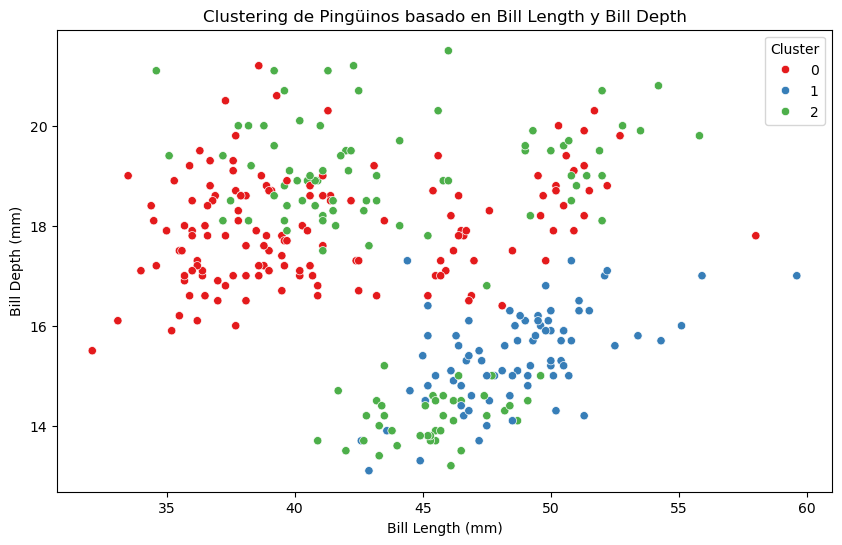

In [ ]:
# Importando librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans  


# Cargando el dataset de pingüinos
df = sns.load_dataset('penguins')

# Mostrando las primeras filas del dataset
print('Primeros registros del dataset de pingüinos:')
display(df.head())

# Preprocesando la informacion y limpiandola
df_sin_NAN = df.dropna()

df_cat = pd.get_dummies(df_sin_NAN, columns=['island'], prefix='island', dtype=int)
df_cat['sex'] = df_cat['sex'].map({'Male': 1, 'Female': 0})

# Mostrando las primeras filas del dataset preprocesado con one-hot encoding y label encoding
display(df_cat.head(15))

df_cat.drop(columns=['species'], inplace=True)

# Mostrando la matriz de correlación
print("Matriz de correlación de los datos de pingüinos:")
display(df_cat.corr('pearson'))

# Realizando un KMEANS con K=3

# Seleccionando las características para el clustering
X = df_cat.values
# Aplicando KMeans con K=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)   
# Obteniendo las etiquetas de los clusters
labels = kmeans.labels_
# Agregando las etiquetas al DataFrame original
df_cat['Cluster'] = labels
# Mostrando las primeras filas del DataFrame con las etiquetas de los clusters
print("Primeros registros del dataset con etiquetas de clusters:")
display(df_cat.head())
# Visualizando los clusters utilizando un par de características
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cat, x='bill_length_mm', y='bill_depth_mm',
                hue='Cluster', palette='Set1')
plt.title('Clustering de Pingüinos basado en Bill Length y Bill Depth')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.legend(title='Cluster')
plt.show()